In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from keras import *
import os
import random
import cv2
import warnings
warnings.filterwarnings('ignore')

2025-06-16 14:19:12.524713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750083552.776700      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750083552.850366      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#### Load data

In [2]:
def load_data(path,size = 150):
    data = []
    label = []
    for dirname in os.listdir(path):
        if dirname == 'NORMAL':
            for file in os.listdir(path + dirname):
                img = cv2.imread(path + dirname+'/'+ file, cv2.IMREAD_GRAYSCALE)
                rescaled_image = cv2.resize(img,(size,size))
                data.append(rescaled_image)
                label.append('NORMAL')
        else:
            for file in os.listdir(path + dirname):
                img = cv2.imread(path + dirname+'/'+ file, cv2.IMREAD_GRAYSCALE)
                rescaled_image = cv2.resize(img,(size,size))
                data.append(rescaled_image)
                label.append('PNEUMONIA')
    return data,label
                

In [3]:
training_data_original,training_label_original  = load_data('/kaggle/input/chest_xray/train/')
test_data_original,test_label_original  = load_data('/kaggle/input/chest_xray/test/')
val_data_original,val_label_original  = load_data('/kaggle/input/chest_xray/val/')
#/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0115-0001.jpeg
#cv2.imread('/kaggle/input/chest-xray-pneumonia/chest_xray/train/')
#os.listdir('/kaggle/input/')

In [4]:
training_data = np.array(training_data_original)
training_label = np.array(training_label_original)

test_data = np.array(test_data_original)
test_label = np.array(test_label_original)

val_data = np.array(val_data_original)
val_label = np.array(val_label_original)

#### Shuffle Dataset

In [5]:
training_perm = np.random.permutation(training_data.shape[0])
test_perm = np.random.permutation(test_data.shape[0])
val_perm = np.random.permutation(val_data.shape[0])

training_data = training_data[training_perm]
training_label = training_label[training_perm]

'''test_data = test_data[test_perm]
test_label = test_label[test_perm]

val_data = val_data[val_perm]
val_label = val_label[val_perm]'''

'test_data = test_data[test_perm]\ntest_label = test_label[test_perm]\n\nval_data = val_data[val_perm]\nval_label = val_label[val_perm]'

#### Data Visulaization

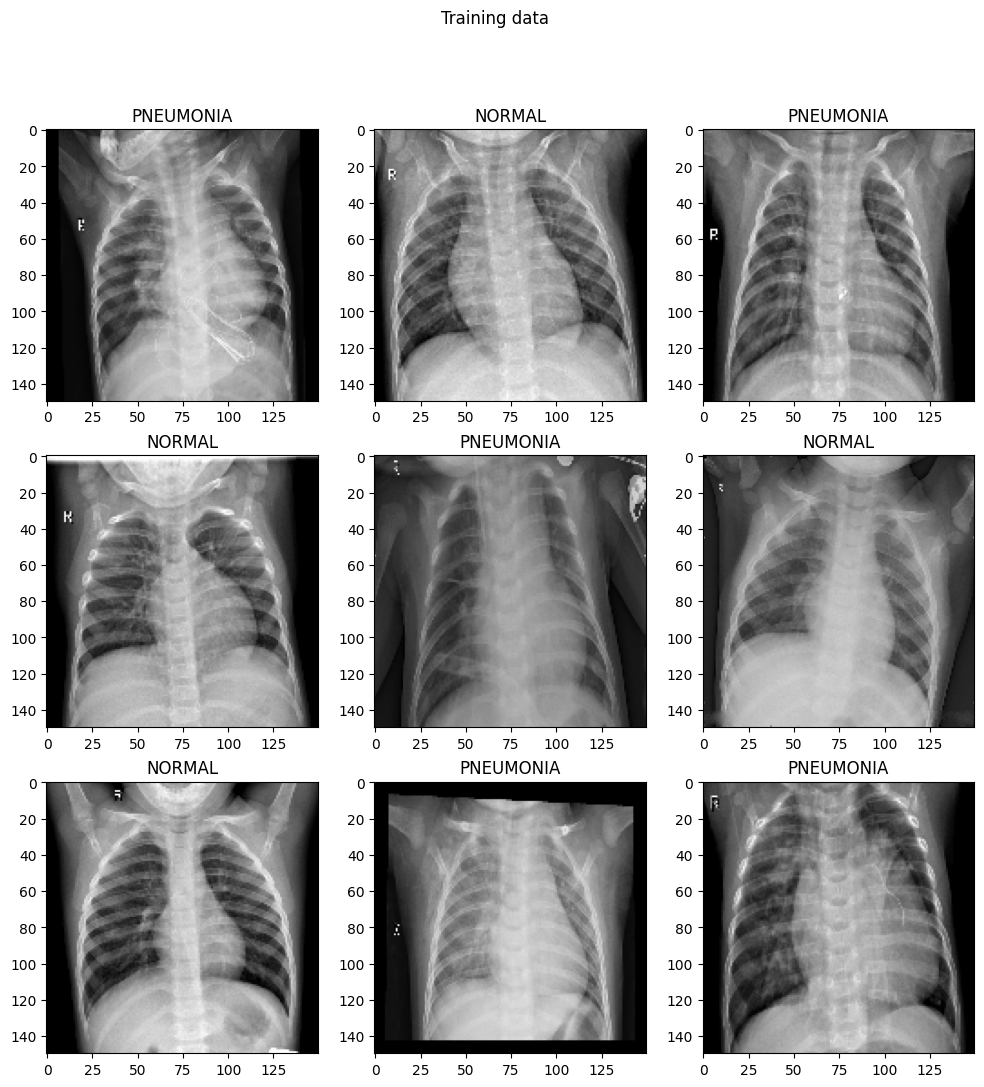

In [6]:
_,axs = plt.subplots(3,3, figsize = (12,12))

for ax in axs.flatten():
    plt.suptitle('Training data')
    random_index = random.randint(0,training_data.shape[0]-1)
    ax.imshow(training_data[random_index], cmap = 'gray')
    ax.set_title(training_label[random_index])

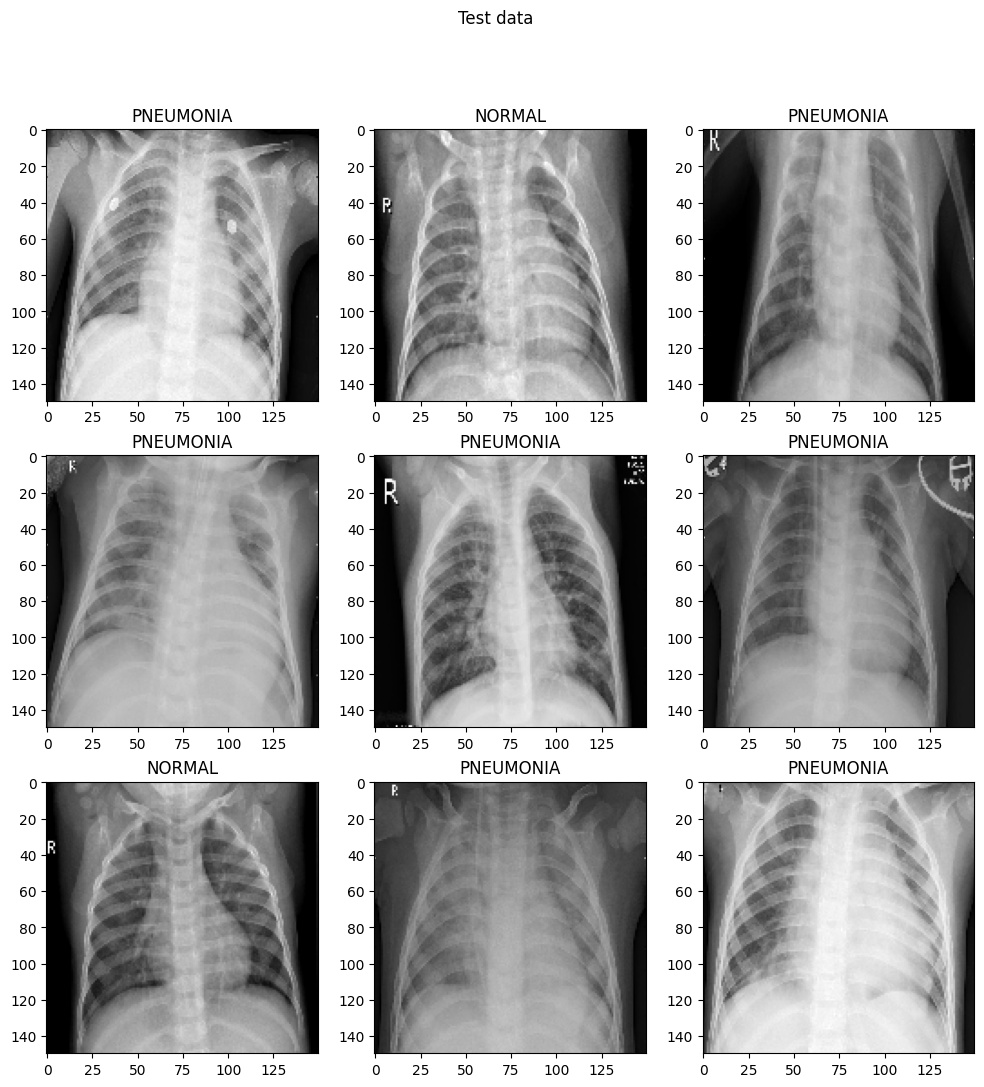

In [7]:
_,axs = plt.subplots(3,3, figsize = (12,12))

for ax in axs.flatten():
    plt.suptitle('Test data')
    random_index = random.randint(0,test_data.shape[0]-1)
    ax.imshow(test_data[random_index], cmap = 'gray')
    ax.set_title(test_label[random_index])

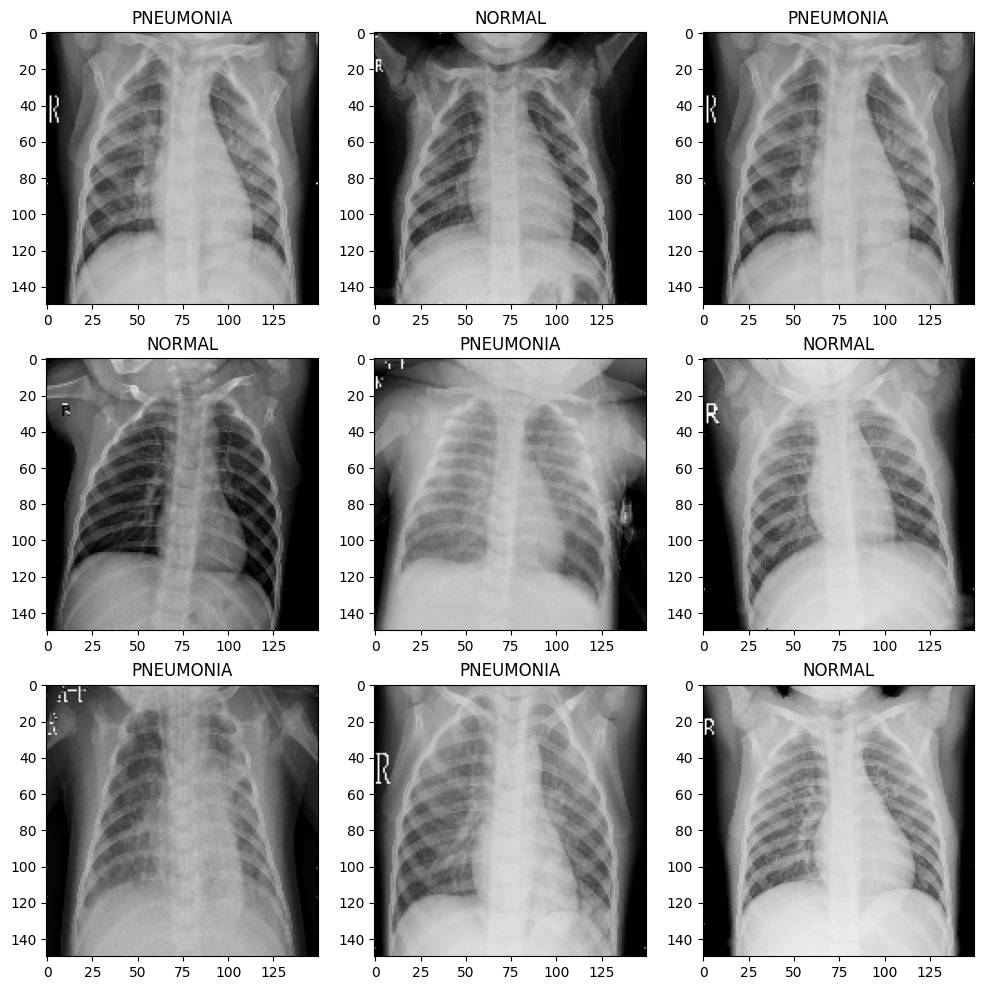

In [8]:
_,axs = plt.subplots(3,3, figsize = (12,12))

for ax in axs.flatten():
    plt.title('Validation data')
    random_index = random.randint(0,val_data.shape[0]-1)
    ax.imshow(val_data[random_index], cmap = 'gray')
    ax.set_title(val_label[random_index])

#### Data Preprocessing

<Axes: ylabel='count'>

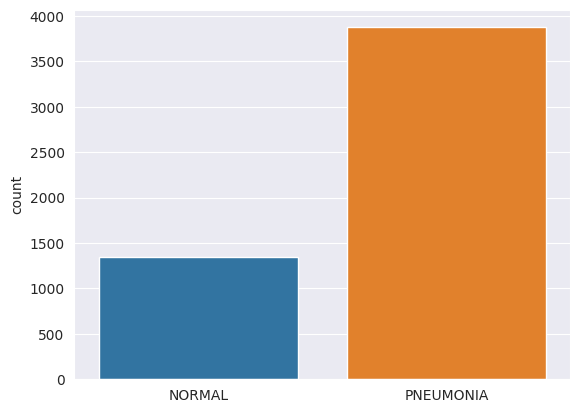

In [9]:
sns.set_style('darkgrid')
sns.countplot(x = training_label)

#### The data set is not balanced. We need to generate data to balance the dataset.
* Train a model with imbalanced data
* Train a model with balanced generated data and compare the results

#### Label encoding

In [10]:
training_encoder = LabelEncoder()

training_label_encoded = training_encoder.fit_transform(training_label)

In [11]:
val_label_encoded = training_encoder.transform(val_label)

In [12]:
test_label_encoded = training_encoder.transform(test_label)

#### Scaling

In [13]:
training_data_scaled = training_data / 255
val_data_scaled = val_data / 255
test_data_scaled = test_data / 255

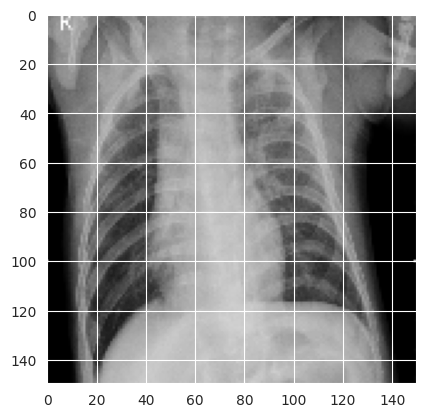

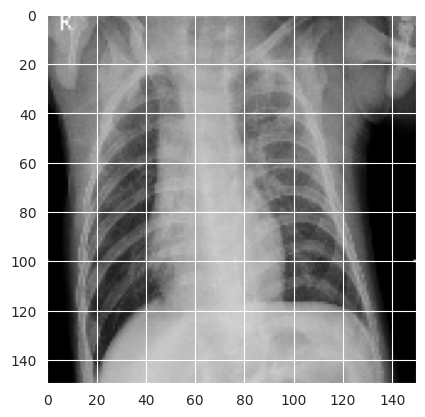

In [14]:
training_data_scaled
plt.imshow(test_data[1], cmap = 'gray')
plt.show()
plt.imshow(test_data_scaled[1], cmap = 'gray')

### Model training with imbalanced Data

In [15]:
training_data.shape

(5216, 150, 150)

In [137]:
model_nn_not_balanced = tf.keras.models.Sequential([
    tf.keras.Input(shape=(150,150)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(128,activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

In [142]:
model_nn_not_balanced.compile(optimizer = 'adam',
              loss = tf.keras.losses.BinaryCrossentropy(),
              metrics = ['accuracy'])

In [143]:
model_nn_not_balanced.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)                  │ (None, 22500)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 128)                 │       2,880,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,896,769 (11.05 MB)

 Trainable params: 2,896,769 (11.05 MB)

 Non-trainable params: 0 (0.00 B)

In [144]:
history_nn_not_balanced  = model_nn_not_balanced.fit(training_data_scaled, training_label_encoded, epochs = 20, validation_data = (val_data_scaled, val_label_encoded), batch_size = 32)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8027 - loss: 0.8498 - val_accuracy: 0.5625 - val_loss: 1.1650
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9065 - loss: 0.2691 - val_accuracy: 0.9375 - val_loss: 0.2890
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9327 - loss: 0.1728 - val_accuracy: 0.7500 - val_loss: 0.4606
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9361 - loss: 0.1803 - val_accuracy: 0.7500 - val_loss: 0.6039
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9442 - loss: 0.1347 - val_accuracy: 0.7500 - val_loss: 0.5497
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9489 - loss: 0.1396 - val_accuracy: 0.9375 - val_loss: 0.2342
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9548 - loss: 0.1142 - val_accuracy: 0.6875 - val_loss: 0.6684
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9444 - loss: 0.1429 - val_accu

### Model Evaluation

In [145]:
model_nn_not_balanced.evaluate(training_data_scaled, training_label_encoded)

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9748 - loss: 0.0644


[0.06975052505731583, 0.9741181135177612]

In [146]:
training_label_predicted  = (model_nn_not_balanced.predict(training_data_scaled) > 0.5).astype(int)

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


#### Classification Report

In [147]:
print(classification_report(training_label_encoded,training_label_predicted.astype(int)))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      1341
           1       0.99      0.97      0.98      3875

    accuracy                           0.97      5216
   macro avg       0.96      0.97      0.97      5216
weighted avg       0.97      0.97      0.97      5216



#### Data Visualization

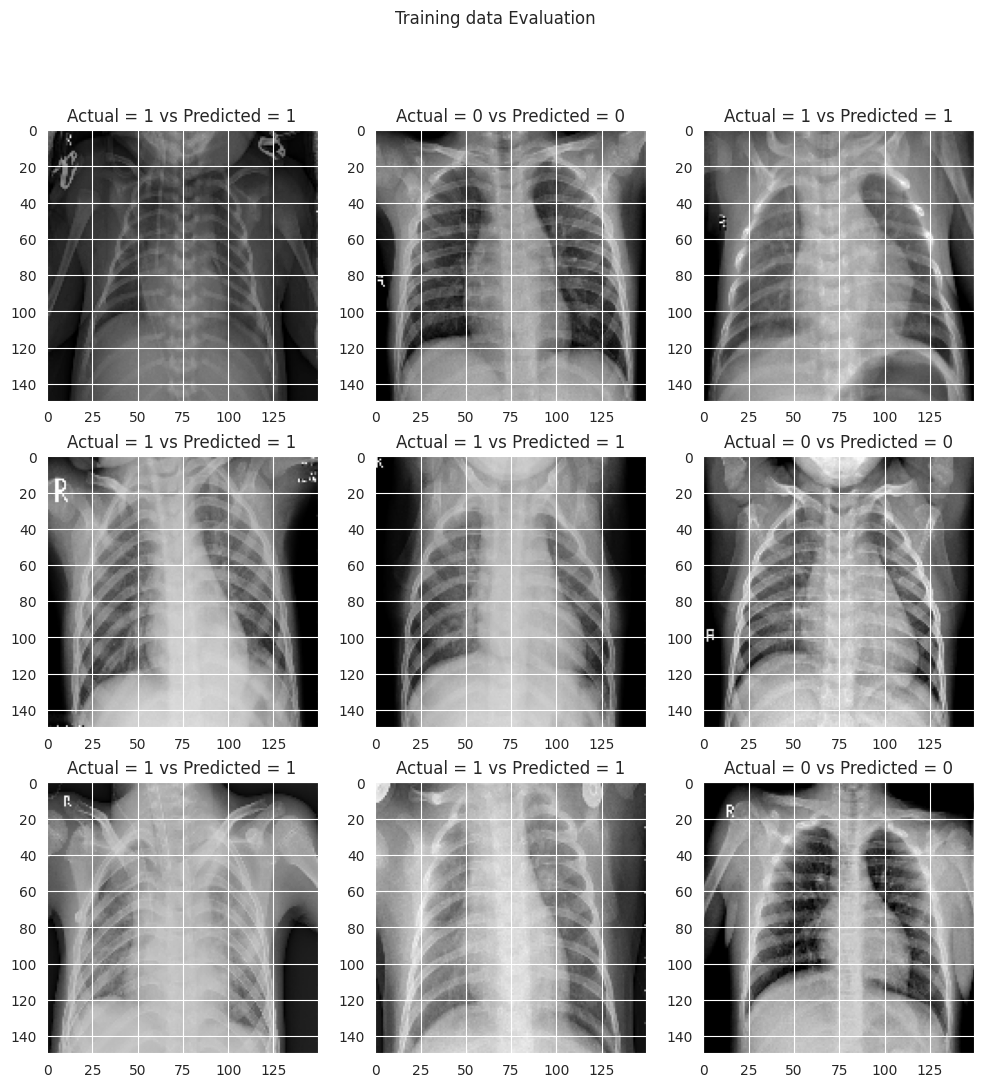

In [86]:
_,axs = plt.subplots(3,3, figsize = (12,12))

for ax in axs.flatten():
    plt.suptitle('Training data Evaluation')
    random_index = random.randint(0,training_data.shape[0]-1)
    ax.imshow(training_data[random_index], cmap='gray')
    ax.set_title(f'Actual = {training_label_encoded[random_index]} vs Predicted = {training_label_predicted.reshape(-1).astype(int)[random_index]}')

#### Heatmap (confusion matrix)

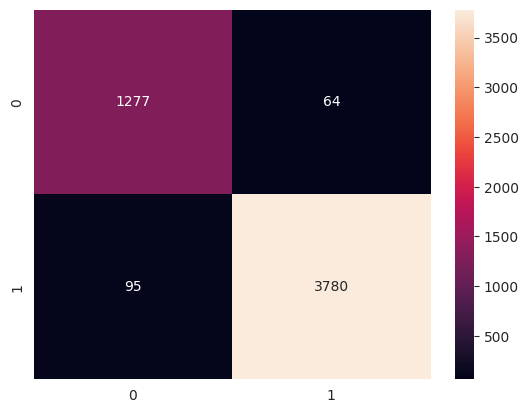

In [87]:
sns.heatmap(confusion_matrix(training_label_encoded,training_label_predicted.astype(int)), annot = True , fmt = '.0f')
plt.show()

### Model Validation

In [88]:
model.evaluate(val_data_scaled, val_label_encoded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8750 - loss: 0.2678


[0.2678268849849701, 0.875]

In [89]:
val_label_predicted  = (model.predict(val_data_scaled) > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [90]:
print(classification_report(val_label_encoded,val_label_predicted.astype(int)))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.80      1.00      0.89         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16



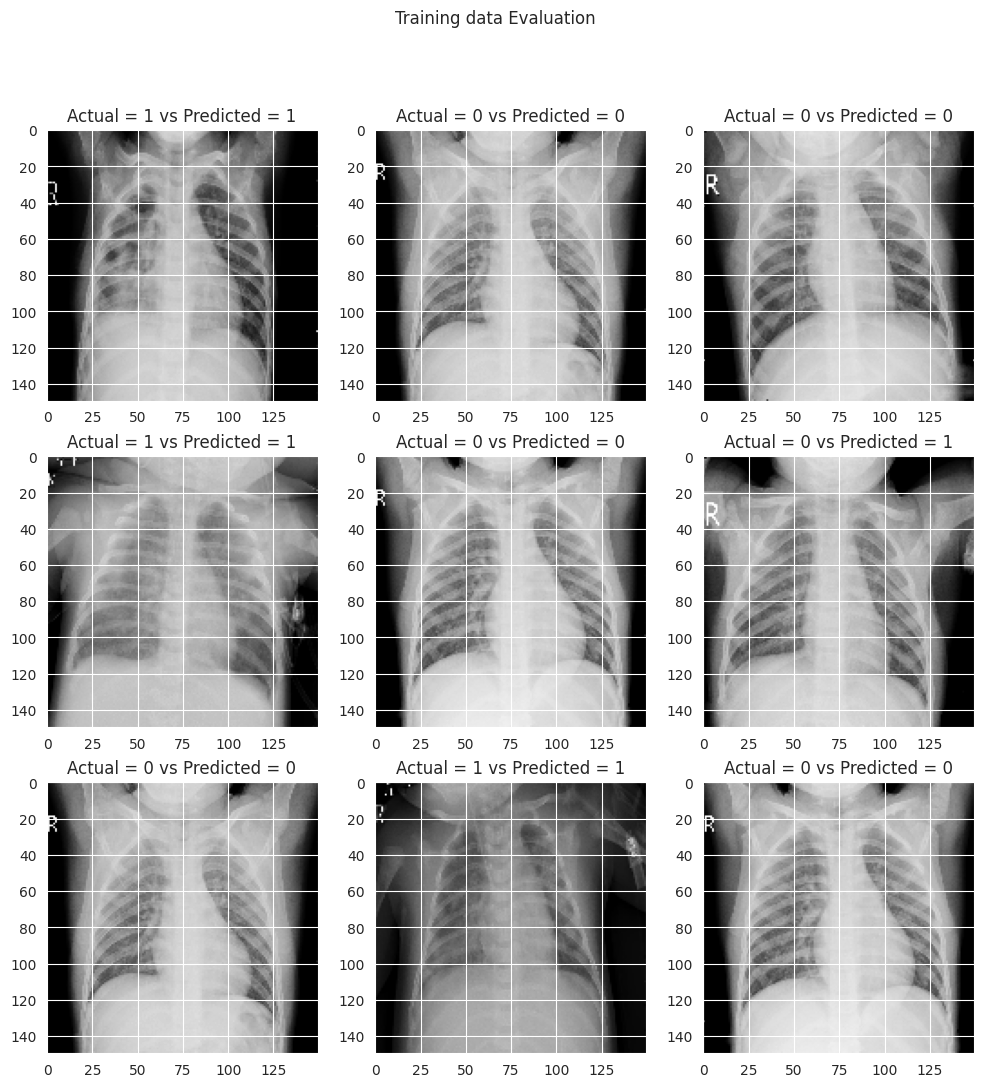

In [91]:
_,axs = plt.subplots(3,3, figsize = (12,12))

for ax in axs.flatten():
    plt.suptitle('Training data Evaluation')
    random_index = random.randint(0,val_data.shape[0]-1)
    ax.imshow(val_data[random_index], cmap = 'gray')
    ax.set_title(f'Actual = {val_label_encoded[random_index]} vs Predicted = {val_label_predicted.reshape(-1).astype(int)[random_index]}')

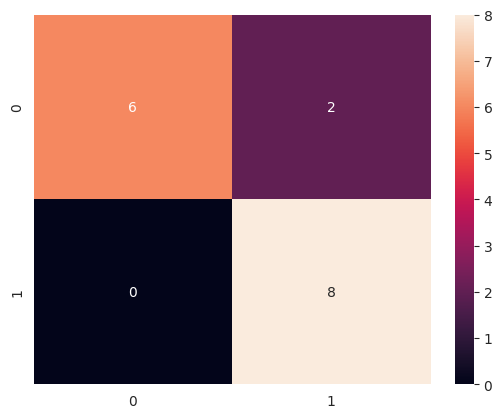

In [92]:
sns.heatmap(confusion_matrix(val_label_encoded,val_label_predicted.astype(int)), annot = True , fmt = '.0f')
plt.show()

### Model Testing

In [93]:
model.evaluate(test_data_scaled, test_label_encoded)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9261 - loss: 0.2266


[0.6383675932884216, 0.7676281929016113]

In [94]:
test_label_predicted  = (model.predict(test_data_scaled) > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [55]:
print(classification_report(test_label_encoded,test_label_predicted.astype(int)))

              precision    recall  f1-score   support

           0       0.87      0.58      0.69       234
           1       0.79      0.95      0.86       390

    accuracy                           0.81       624
   macro avg       0.83      0.76      0.78       624
weighted avg       0.82      0.81      0.80       624



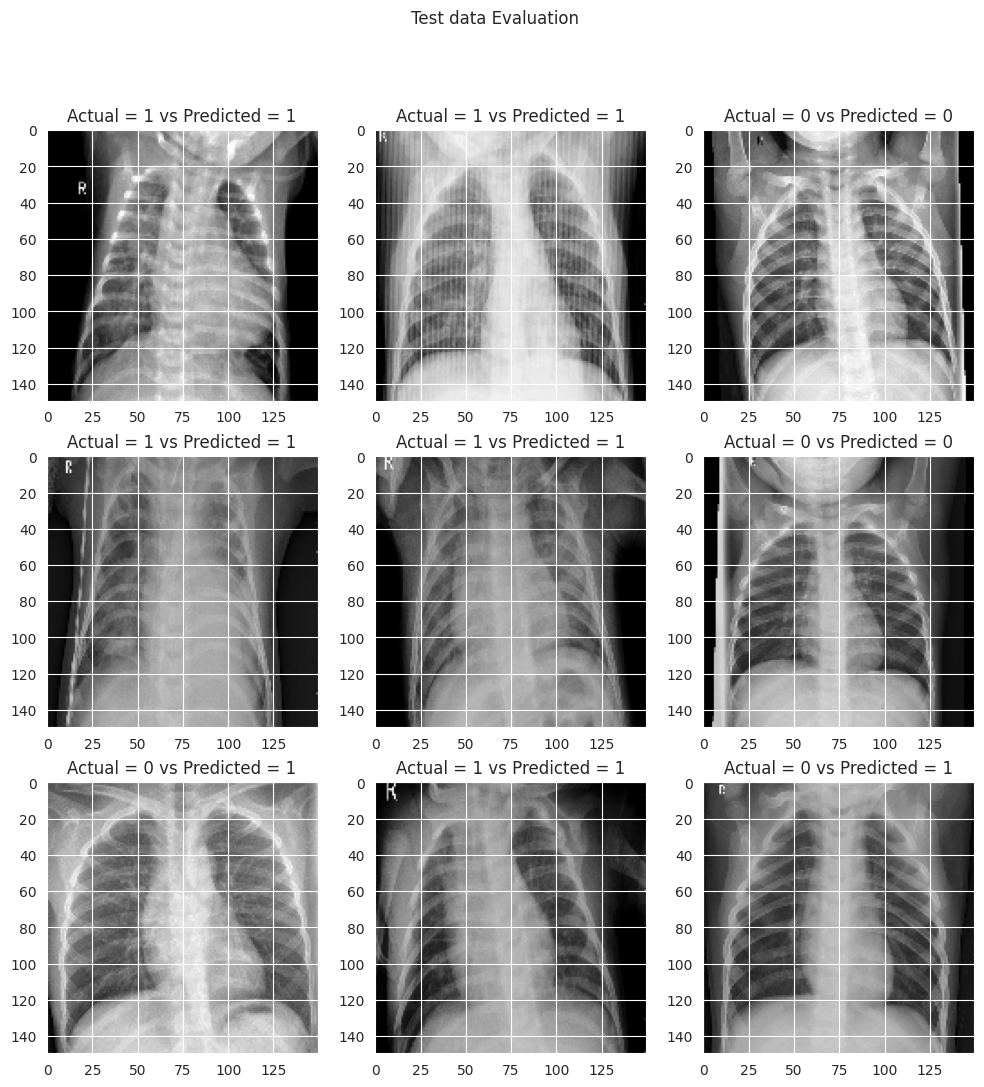

In [56]:
_,axs = plt.subplots(3,3, figsize = (12,12))

for ax in axs.flatten():
    plt.suptitle('Test data Evaluation')
    random_index = random.randint(0,test_data.shape[0]-1)
    ax.imshow(test_data[random_index], cmap = 'gray')
    ax.set_title(f'Actual = {test_label_encoded[random_index]} vs Predicted = {test_label_predicted.reshape(-1).astype(int)[random_index]}')

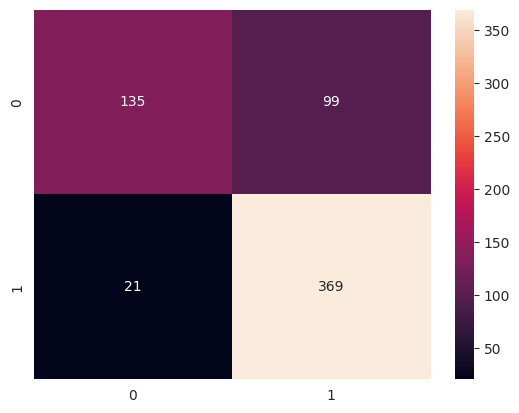

In [57]:
sns.heatmap(confusion_matrix(test_label_encoded,test_label_predicted.astype(int)), annot = True , fmt = '.0f')
plt.show()

In [58]:
history.history

{'accuracy': [0.7620782256126404,
  0.8847776055335999,
  0.9376916885375977,
  0.9183282256126404,
  0.9455521702766418,
  0.9507285356521606,
  0.9468941688537598,
  0.9472776055335999,
  0.9562883377075195,
  0.9545629024505615,
  0.9553297758102417,
  0.9624233245849609,
  0.9578220844268799,
  0.962806761264801,
  0.9601227045059204,
  0.9656825065612793,
  0.9605061411857605,
  0.9560966491699219,
  0.9405674934387207,
  0.9468941688537598],
 'loss': [0.7697053551673889,
  0.28198370337486267,
  0.1674174666404724,
  0.1998445987701416,
  0.1458122283220291,
  0.13155706226825714,
  0.13859763741493225,
  0.1398869901895523,
  0.11587392538785934,
  0.12092937529087067,
  0.12463836371898651,
  0.1023392379283905,
  0.1100144162774086,
  0.10221759974956512,
  0.1022956445813179,
  0.09397096931934357,
  0.10032635927200317,
  0.11451959609985352,
  0.1528906673192978,
  0.13544873893260956],
 'val_accuracy': [0.8125,
  0.875,
  0.875,
  0.8125,
  0.75,
  0.9375,
  0.9375,
  0.87

### Model Analysis

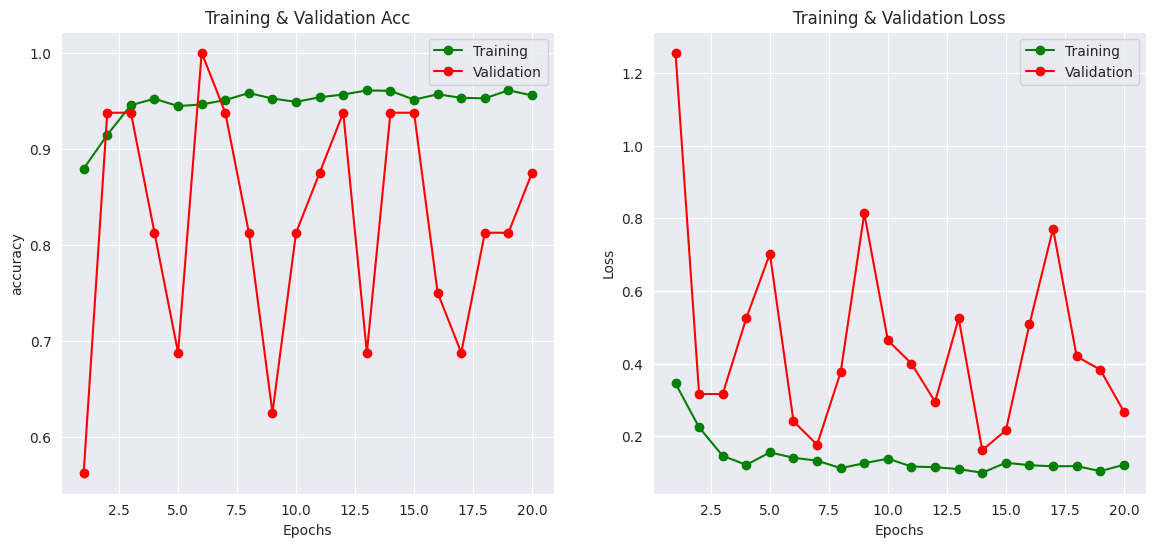

In [95]:
epochs = [x + 1 for x in range(len(history.history['accuracy']))]
_,axs = plt.subplots(1,2 ,figsize = (14,6))
axs[0].plot(epochs,history.history['accuracy'], 'go-',label = 'Training')
axs[0].plot(epochs, history.history['val_accuracy'],'ro-',label = 'Validation')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('accuracy')
axs[0].legend()
axs[0].set_title('Training & Validation Acc')

axs[1].plot(epochs,history.history['loss'], 'go-',label = 'Training')
axs[1].plot(epochs, history.history['val_loss'],'ro-',label = 'Validation')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].set_title('Training & Validation Loss')
plt.show()

### Data Augmentation

#### Increase number of Normal sample

In [98]:
data_augmentation = tf.keras.models.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomZoom(0.4)])
   
''' tf.keras.layers.RandomBrightness(0.3, value_range=[0,1])
])'''

' tf.keras.layers.RandomBrightness(0.3, value_range=[0,1])\n])'

In [99]:
x_training_normal = training_data_scaled[training_label == 'NORMAL']

In [100]:
x_training_normal_tensor = tf.convert_to_tensor(x_training_normal[:700])
x_training_normal_tensor = tf.expand_dims(x_training_normal_tensor , axis = -1)
#x = tf.cast(x, tf.float32) / 255.0

In [101]:
x_training_augmentated = np.zeros(shape = (1,150,150,1))
for i in range(3):
    x_training_augmentated = np.vstack((x_training_augmentated,data_augmentation(x_training_normal_tensor)))
    

In [102]:
x_training_augmentated = x_training_augmentated.reshape(x_training_augmentated.shape[0],150,150)

In [103]:
x_training_augmentated = x_training_augmentated[1:]

In [104]:
training_data_scaled_with_augmentation = np.vstack((training_data_scaled,x_training_augmentated))

In [105]:
trainig_label_augmentated = np.zeros(shape = (x_training_augmentated.shape[0])).reshape(-1,1)

In [106]:
trainig_label_augmentated.shape

(2100, 1)

In [107]:
trainig_label_augmented_not_encoded = np.full(x_training_augmentated.shape[0], fill_value = 'NORMAL').reshape(-1,1)

In [109]:
training_label_with_augmented_encoded = np.vstack((training_label_encoded.reshape(-1,1), trainig_label_augmentated)).reshape(-1)

In [110]:
trainig_label_with_augmented_not_encoded = np.vstack((training_label.reshape(-1,1), trainig_label_augmented_not_encoded)).reshape(-1)

In [113]:
training_label_with_augmented_encoded.shape

(7316,)

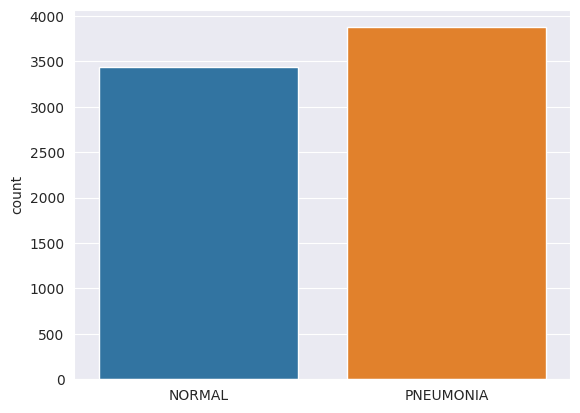

In [114]:
sns.countplot(x = trainig_label_with_augmented_not_encoded)
plt.show()

### Train Model(Neural Network) with balanced data

In [115]:
model_balanced = tf.keras.models.Sequential([
    tf.keras.Input(shape=(150,150)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(128,activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

'''model_balanced = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # 2 classes: NORMAL and PNEUMONIA
])'''

"model_balanced = Sequential([\n    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,1)),\n    layers.MaxPooling2D((2,2)),\n    layers.Conv2D(64, (3,3), activation='relu'),\n    layers.MaxPooling2D((2,2)),\n    layers.Conv2D(128, (3,3), activation='relu'),\n    layers.MaxPooling2D((2,2)),\n    layers.Flatten(),\n    layers.Dense(128, activation='relu'),\n    layers.Dropout(0.5),\n    layers.Dense(1, activation='sigmoid')  # 2 classes: NORMAL and PNEUMONIA\n])"

In [116]:
model_balanced.compile(optimizer = 'adam',
              loss = tf.keras.losses.BinaryCrossentropy(),
              metrics = ['accuracy'])

In [119]:
history = model_balanced.fit(training_data_scaled_with_augmentation, training_label_with_augmented_encoded, epochs = 5, validation_data=(val_data_scaled, val_label_encoded), batch_size = 32)

Epoch 1/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6976 - loss: 1.0650 - val_accuracy: 0.7500 - val_loss: 0.4043
Epoch 2/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8825 - loss: 0.2790 - val_accuracy: 0.6250 - val_loss: 1.1084
Epoch 3/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9000 - loss: 0.2421 - val_accuracy: 0.8750 - val_loss: 0.2471
Epoch 4/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9308 - loss: 0.1764 - val_accuracy: 0.8125 - val_loss: 0.4182
Epoch 5/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9349 - loss: 0.1681 - val_accuracy: 0.8750 - val_loss: 0.2232


#### Model Analysis

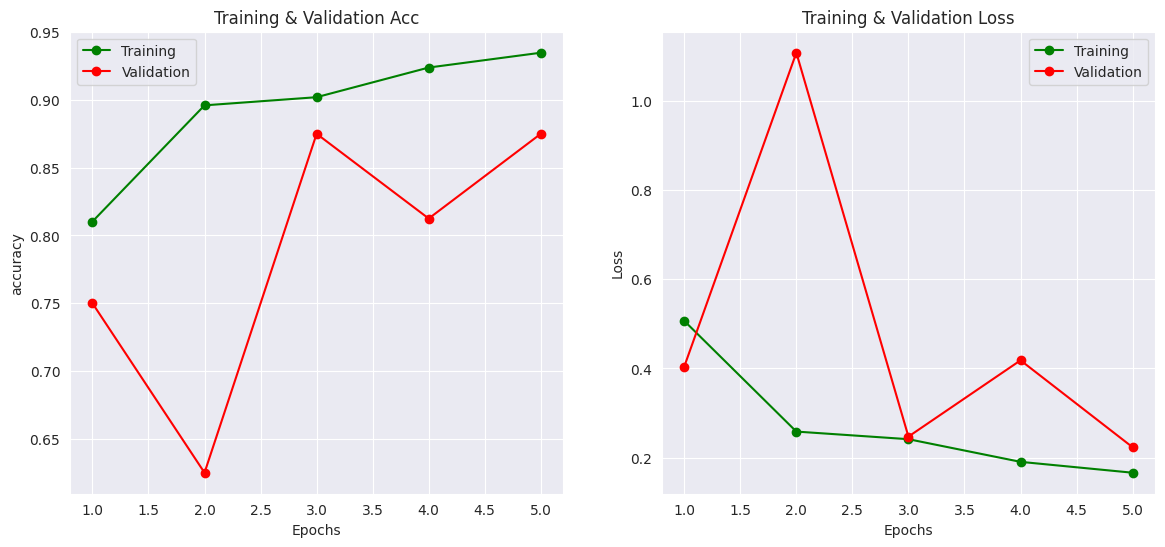

In [120]:
epochs = [x + 1 for x in range(len(history.history['accuracy']))]
_,axs = plt.subplots(1,2 ,figsize = (14,6))
axs[0].plot(epochs,history.history['accuracy'], 'go-',label = 'Training')
axs[0].plot(epochs, history.history['val_accuracy'],'ro-',label = 'Validation')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('accuracy')
axs[0].legend()
axs[0].set_title('Training & Validation Acc')

axs[1].plot(epochs,history.history['loss'], 'go-',label = 'Training')
axs[1].plot(epochs, history.history['val_loss'],'ro-',label = 'Validation')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].set_title('Training & Validation Loss')
plt.show()

#### Model performance on Test Data

In [121]:
model.evaluate(test_data_scaled, test_label_encoded)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9261 - loss: 0.2266


[0.6383675932884216, 0.7676281929016113]

In [122]:
test_label_predicted  = (model.predict(test_data_scaled) > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


              precision    recall  f1-score   support

           0       0.94      0.41      0.57       234
           1       0.73      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.70      0.70       624
weighted avg       0.81      0.77      0.74       624



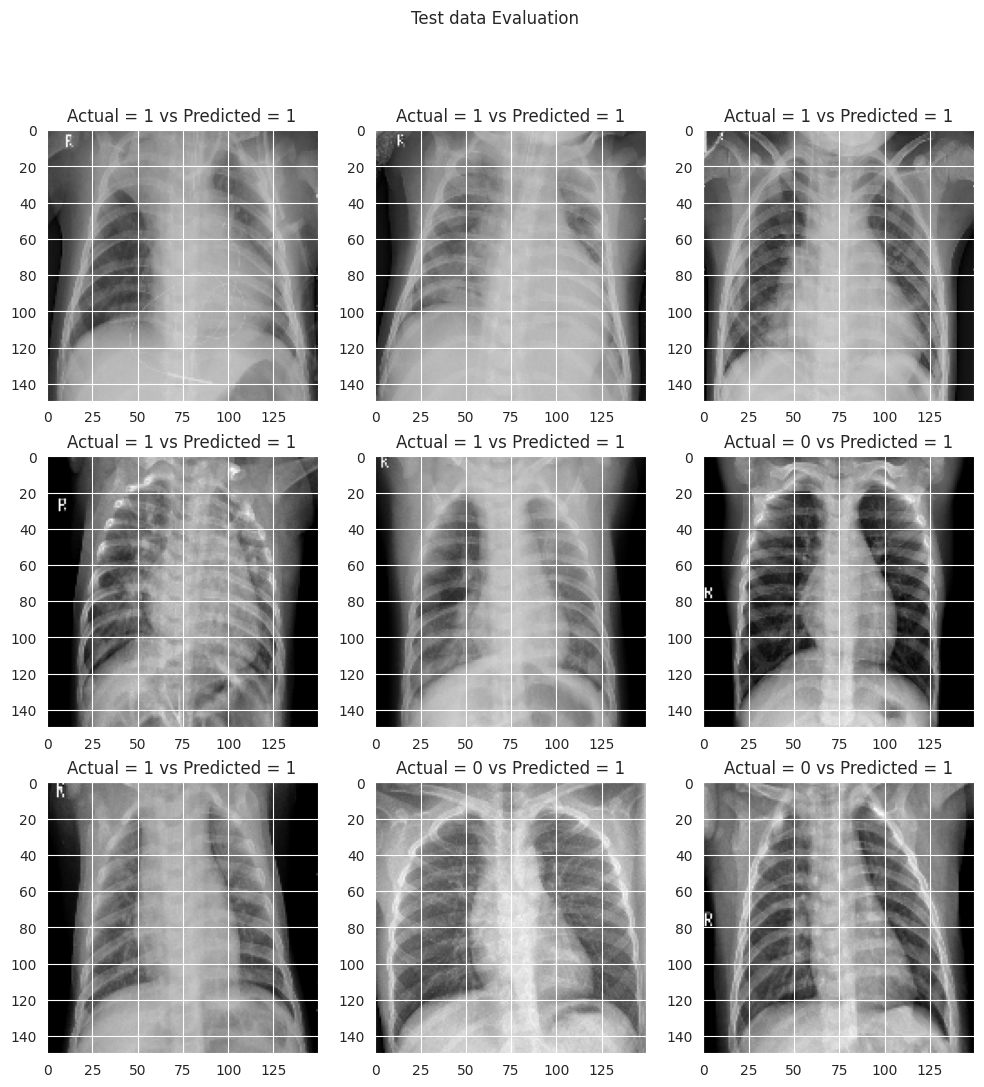

In [123]:
print(classification_report(test_label_encoded,test_label_predicted.astype(int)))
_,axs = plt.subplots(3,3, figsize = (12,12))

for ax in axs.flatten():
    plt.suptitle('Test data Evaluation')
    random_index = random.randint(0,test_data.shape[0]-1)
    ax.imshow(test_data[random_index], cmap = 'gray')
    ax.set_title(f'Actual = {test_label_encoded[random_index]} vs Predicted = {test_label_predicted.reshape(-1).astype(int)[random_index]}')

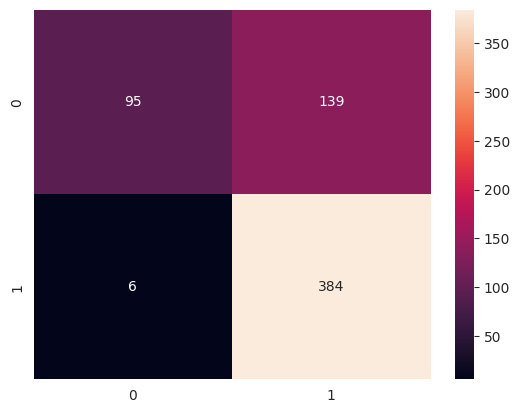

In [124]:
sns.heatmap(confusion_matrix(test_label_encoded,test_label_predicted.astype(int)), annot = True , fmt = '.0f')
plt.show()

#### CNN

In [125]:
model_balanced_cnn = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # 2 classes: NORMAL and PNEUMONIA
])

In [130]:
model_balanced_cnn.compile(optimizer = 'adam',
              loss = tf.keras.losses.BinaryCrossentropy(),
              metrics = ['accuracy']
)

In [131]:
history_cnn = model_balanced_cnn.fit(training_data_scaled_with_augmentation, training_label_with_augmented_encoded, epochs = 5, validation_data=(val_data_scaled, val_label_encoded), batch_size = 32)

Epoch 1/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 173s 737ms/step - accuracy: 0.7644 - loss: 0.4471 - val_accuracy: 0.8125 - val_loss: 0.3837
Epoch 2/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 202s 739ms/step - accuracy: 0.9489 - loss: 0.1401 - val_accuracy: 0.8125 - val_loss: 0.4557
Epoch 3/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 202s 739ms/step - accuracy: 0.9557 - loss: 0.1189 - val_accuracy: 0.8750 - val_loss: 0.2974
Epoch 4/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 168s 732ms/step - accuracy: 0.9753 - loss: 0.0784 - val_accuracy: 0.9375 - val_loss: 0.2266
Epoch 5/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 167s 730ms/step - accuracy: 0.9746 - loss: 0.0666 - val_accuracy: 1.0000 - val_loss: 0.0747


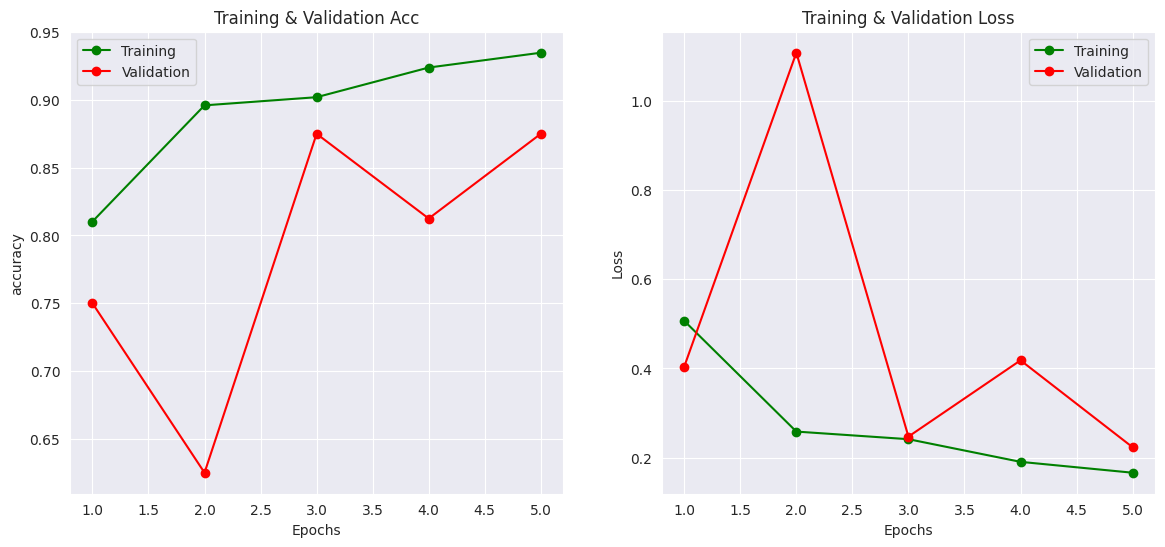

In [132]:
epochs = [x + 1 for x in range(len(history_cnn.history['accuracy']))]
_,axs = plt.subplots(1,2 ,figsize = (14,6))
axs[0].plot(epochs,history.history['accuracy'], 'go-',label = 'Training')
axs[0].plot(epochs, history.history['val_accuracy'],'ro-',label = 'Validation')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('accuracy')
axs[0].legend()
axs[0].set_title('Training & Validation Acc')

axs[1].plot(epochs,history.history['loss'], 'go-',label = 'Training')
axs[1].plot(epochs, history.history['val_loss'],'ro-',label = 'Validation')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].set_title('Training & Validation Loss')
plt.show()

In [133]:
model_balanced_cnn.evaluate(test_data_scaled, test_label_encoded)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.9300 - loss: 0.3117


[0.9754418730735779, 0.7996794581413269]

In [134]:
test_label_predicted  = (model_balanced_cnn.predict(test_data_scaled) > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step


              precision    recall  f1-score   support

           0       0.97      0.48      0.64       234
           1       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.74      0.75       624
weighted avg       0.84      0.80      0.78       624



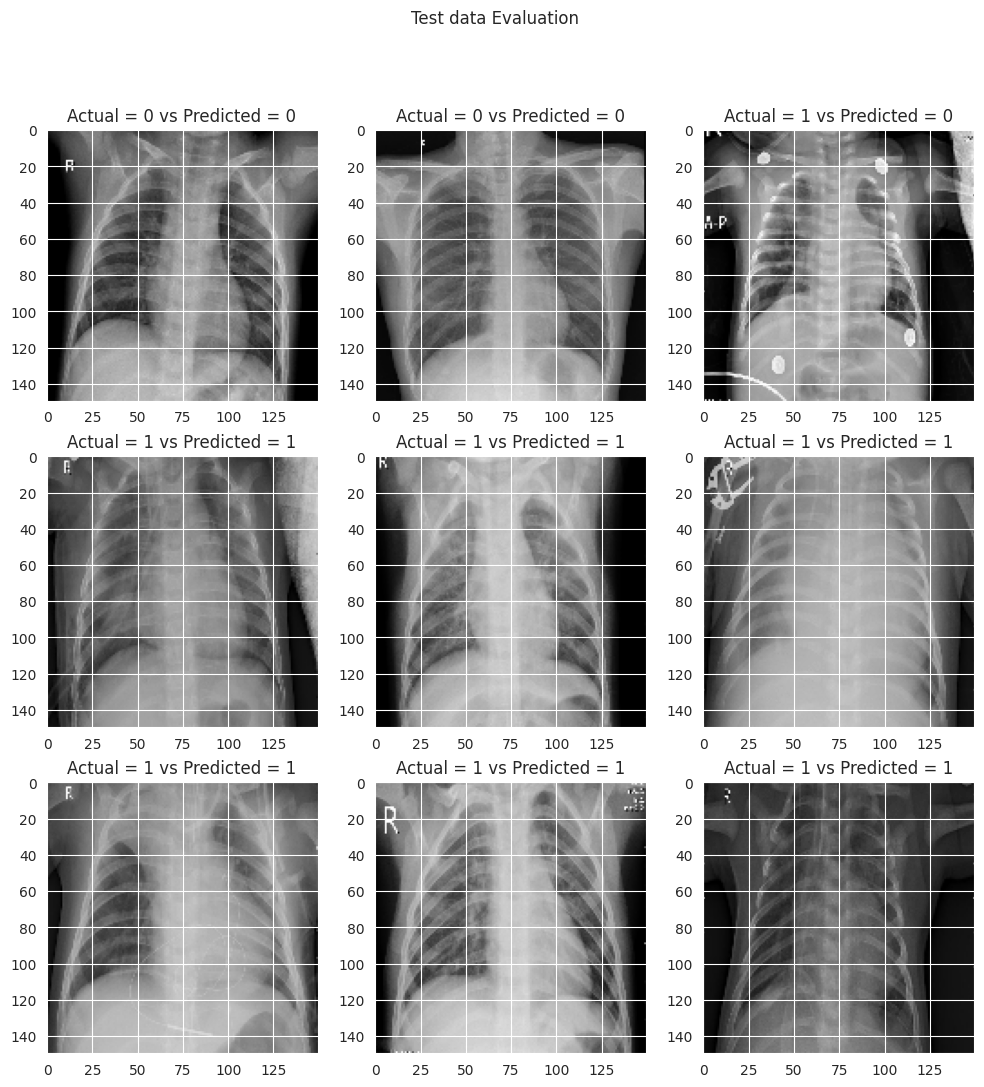

In [135]:
print(classification_report(test_label_encoded,test_label_predicted.astype(int)))
_,axs = plt.subplots(3,3, figsize = (12,12))

for ax in axs.flatten():
    plt.suptitle('Test data Evaluation')
    random_index = random.randint(0,test_data.shape[0]-1)
    ax.imshow(test_data[random_index], cmap = 'gray')
    ax.set_title(f'Actual = {test_label_encoded[random_index]} vs Predicted = {test_label_predicted.reshape(-1).astype(int)[random_index]}')

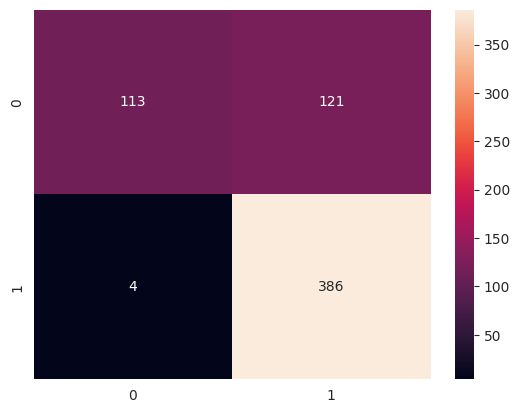

In [136]:
sns.heatmap(confusion_matrix(test_label_encoded,test_label_predicted.astype(int)), annot = True , fmt = '.0f')
plt.show()